In [ ]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 46.2 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

# Dataset Audit

🚀 STARTING DATASET AUDIT

📊 Summary Statistics:
   • Total valid images scanned: 4341
   • Attentive: 1813 images (41.76%)
   • Distracted: 1168 images (26.91%)
   • Drowsy: 1360 images (31.33%)

🖼️ File Extension Distribution:
   • .jpg: 4341 files

🛑 Integrity Check:
   • Clean bill of health! No corrupt images found.

📈 Plotting class distribution...


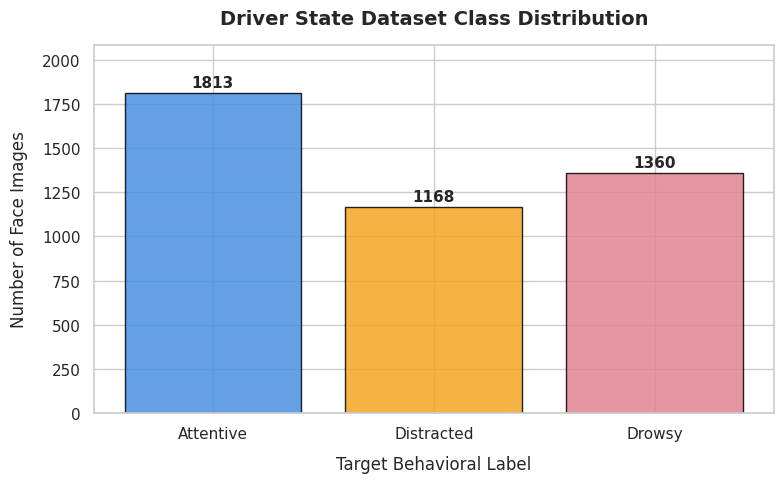

✅ AUDIT TASK FINISHED


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image
from pathlib import Path

def audit_dataset(dataset_path):
    print("=" * 50)
    print("🚀 STARTING DATASET AUDIT")
    print("=" * 50)

    path = Path(dataset_path)

    # 1. Target Subdirectories
    target_classes = ['Attentive', 'Distracted', 'Drowsy']

    # Storage for audit statistics
    class_counts = {}
    extension_counts = Counter()
    total_images = 0
    corrupt_files = []

    # 2. Scan the directory
    for cls in target_classes:
        class_dir = path / cls
        if not class_dir.exists():
            print(f"⚠️ Warning: Class folder '{cls}' not found in {dataset_path}")
            class_counts[cls] = 0
            continue

        images_in_class = 0
        for img_file in class_dir.iterdir():
            if img_file.is_file():
                # Track the file extension
                ext = img_file.suffix.lower()
                extension_counts[ext] += 1
                images_in_class += 1
                total_images += 1

                # Check for file corruptness by attempting to open it
                try:
                    with Image.open(img_file) as img:
                        img.verify() # Quickly verifies image integrity without decoding pixels
                except Exception:
                    corrupt_files.append(str(img_file.relative_to(path)))

        class_counts[cls] = images_in_class

    # 3. Print Text Report
    print(f"\n📊 Summary Statistics:")
    print(f"   • Total valid images scanned: {total_images}")
    for cls, count in class_counts.items():
        percentage = (count / total_images * 100) if total_images > 0 else 0
        print(f"   • {cls}: {count} images ({percentage:.2f}%)")

    print(f"\n🖼️ File Extension Distribution:")
    for ext, count in extension_counts.items():
        print(f"   • {ext or 'no extension'}: {count} files")

    print(f"\n🛑 Integrity Check:")
    if corrupt_files:
        print(f"   • Found {len(corrupt_files)} CORRUPT/UNREADABLE images!")
        print(f"     First few corrupted paths: {corrupt_files[:5]}")
        print("     (Tip: You should delete these files before passing them into PyTorch)")
    else:
        print("   • Clean bill of health! No corrupt images found.")

    # 4. Plot the Distribution Graph
    print("\n📈 Plotting class distribution...")
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    # Create the bar plot
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    colors = ['#4A90E2', '#F5A623', '#E28490'] # Clean aesthetic colors
    bars = plt.bar(classes, counts, color=colors, edgecolor='black', alpha=0.85)

    # Add numbers on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(counts)*0.01),
                 f'{int(yval)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.title("Driver State Dataset Class Distribution", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Target Behavioral Label", fontsize=12, labelpad=10)
    plt.ylabel("Number of Face Images", fontsize=12, labelpad=10)
    plt.ylim(0, max(counts) * 1.15) # Leave room above bars for the numbers

    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print("✅ AUDIT TASK FINISHED")
    print("=" * 50)

# Run the audit on your current directory layout
audit_dataset('/kaggle/input/datasets/natalierobert/designproject-clean')

# Training


⚖️ Stratified Validation Set Distribution Verified:
   • Attentive: 272 images (Exactly ~15% of total class size)
   • Distracted: 176 images (Exactly ~15% of total class size)
   • Drowsy: 204 images (Exactly ~15% of total class size)

Loading MobileNetV3-Large backbone...



Training on device: cuda


Epoch 1/15: 100%|██████████| 116/116 [00:15<00:00,  7.53it/s]


   ↳ Train Loss: 0.4203 | Train Acc: 84.09%
   ↳ Val Loss:   0.1478 | Val Acc:   94.48%
   🌟 Val loss decreased! Saving model weights...


Epoch 2/15: 100%|██████████| 116/116 [00:14<00:00,  8.00it/s]


...

   ↳ Train Loss: 0.0618 | Train Acc: 97.80%
   ↳ Val Loss:   0.0816 | Val Acc:   97.39%
   ⚠️ No val loss improvement. Early Stopping Patience: 1/3


Epoch 5/15: 100%|██████████| 116/116 [00:13<00:00,  8.33it/s]


   ↳ Train Loss: 0.0534 | Train Acc: 97.99%
   ↳ Val Loss:   0.0948 | Val Acc:   96.93%
   ⚠️ No val loss improvement. Early Stopping Patience: 2/3


Epoch 6/15: 100%|██████████| 116/116 [00:13<00:00,  8.31it/s]


   ↳ Train Loss: 0.0472 | Train Acc: 98.18%
   ↳ Val Loss:   0.0714 | Val Acc:   97.85%
   ⚠️ No val loss improvement. Early Stopping Patience: 3/3

🛑 Early stopping triggered! Training stopped at epoch 6 to avoid overfitting.

🎉 Training complete! Best validation accuracy achieved: 97.55%

🔍 Running Final Evaluation on Validation Data...

📝 MISCLASSIFICATION & PERFORMANCE REPORT
              precision    recall  f1-score   support

   Attentive       0.99      0.98      0.98       272
  Distracted       0.95      0.95      0.95       176
      Drowsy       0.98      0.99      0.98       204

    accuracy                           0.98       652
   macro avg       0.97      0.97      0.97       652
weighted avg       0.98      0.98      0.98       652

🔎 Granular Error Identification:

• Class [Attentive]:
  - Total validation items: 272
  - Error Rate: 2.21%
  - ⚠️ Confused 6 times as 'Distracted'

• Class [Distracted]:
  - Total validation items: 176
  - Error Rate: 4.55%
  - ⚠️ Con

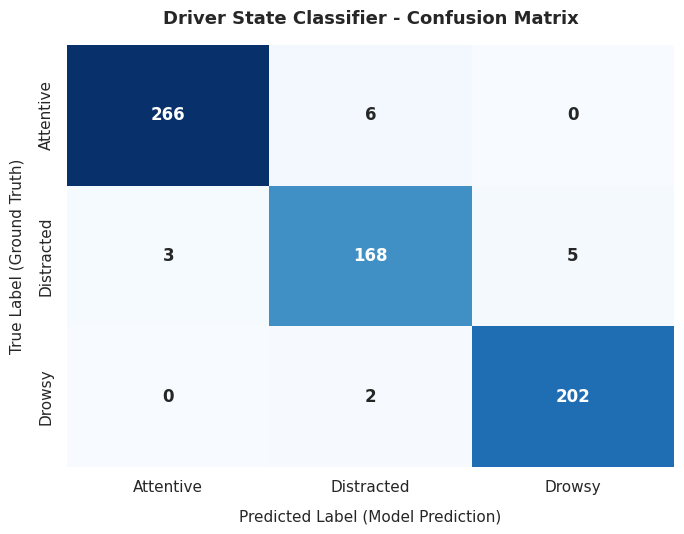

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import timm
from tqdm import tqdm

# =====================================================================
# 1. Configuration & Hyperparameters
# =====================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 15                 # Increased max epochs since Early Stopping will handle cutoff
LEARNING_RATE = 1e-4        # Decreased for safer, more stable fine-tuning
NUM_CLASSES = 3
DATASET_DIR = '/kaggle/input/datasets/natalierobert/designproject-clean'

# --- EARLY STOPPING CONFIGURATION ---
EARLY_STOPPING_PATIENCE = 3  # Stop if validation loss doesn't improve for 3 epochs
MIN_DELTA = 0.001            # Minimum change to qualify as an improvement

# =====================================================================
# 2. Augmentations & Transforms
# =====================================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =====================================================================
# 3. Stratified Dataset Splitting (Fixed Tensor Version)
# =====================================================================
train_dataset_full = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
val_dataset_full = datasets.ImageFolder(root=DATASET_DIR, transform=val_transform)

class_names = train_dataset_full.classes  # ['Attentive', 'Distracted', 'Drowsy']

indices = np.arange(len(train_dataset_full))
targets = np.array(train_dataset_full.targets)

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

val_labels = [targets[i] for i in val_idx]
val_counts = dict(zip(*np.unique(val_labels, return_counts=True)))

print("\n⚖️ Stratified Validation Set Distribution Verified:")
for idx, name in enumerate(class_names):
    print(f"   • {name}: {val_counts[idx]} images (Exactly ~15% of total class size)")

# =====================================================================
# 4. Model Setup
# =====================================================================
print("\nLoading MobileNetV3-Large backbone...")
model = timm.create_model('mobilenetv3_large_100', pretrained=True)
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, NUM_CLASSES)
)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# =====================================================================
# 5. Training Loop with Early Stopping Engine
# =====================================================================
best_val_loss = float('inf')
patience_counter = 0
best_val_acc = 0.0

print(f"\nTraining on device: {DEVICE}")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_idx)
    epoch_train_acc = (correct_train / total_train) * 100

    # Validation Phase
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_idx)
    epoch_val_acc = (correct_val / total_val) * 100

    print(f"   ↳ Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"   ↳ Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")

    # Check for improvement using Validation Loss (industry best practice for early stopping)
    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        best_val_acc = epoch_val_acc
        patience_counter = 0  # Reset counter since improvement occurred
        torch.save(model.state_dict(), '/kaggle/working/best_driver_state_model.pth')
        print("   🌟 Val loss decreased! Saving model weights...")
    else:
        patience_counter += 1
        print(f"   ⚠️ No val loss improvement. Early Stopping Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    # Trigger training termination if patience threshold is met
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping triggered! Training stopped at epoch {epoch+1} to avoid overfitting.")
        break

print(f"\n🎉 Training complete! Best validation accuracy achieved: {best_val_acc:.2f}%")

# =====================================================================
# 6. Evaluation & Analytics (Confusion Matrix & Misclassification)
# =====================================================================
print("\n🔍 Running Final Evaluation on Validation Data...")
model.load_state_dict(torch.load('/kaggle/working/best_driver_state_model.pth'))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

print("\n" + "="*60)
print("📝 MISCLASSIFICATION & PERFORMANCE REPORT")
print("="*60)
print(classification_report(all_targets, all_preds, target_names=class_names))

cm = confusion_matrix(all_targets, all_preds)

print("🔎 Granular Error Identification:")
for i, name in enumerate(class_names):
    total_samples = cm[i].sum()
    correct_samples = cm[i][i]
    misclassified_count = total_samples - correct_samples
    error_rate = (misclassified_count / total_samples) * 100

    print(f"\n• Class [{name}]:")
    print(f"  - Total validation items: {total_samples}")
    print(f"  - Error Rate: {error_rate:.2f}%")

    for j, target_name in enumerate(class_names):
        if i != j and cm[i][j] > 0:
            print(f"  - ⚠️ Confused {cm[i][j]} times as '{target_name}'")

print("\n🖼️ Displaying Confusion Matrix plot...")
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=False, annot_kws={"size": 12, "weight": "bold"})

plt.title("Driver State Classifier - Confusion Matrix", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("True Label (Ground Truth)", fontsize=11, labelpad=10)
plt.xlabel("Predicted Label (Model Prediction)", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

# Reference image

Loading model for visual evaluation...
Weights loaded successfully!

Generating evaluation dashboard snapshot...


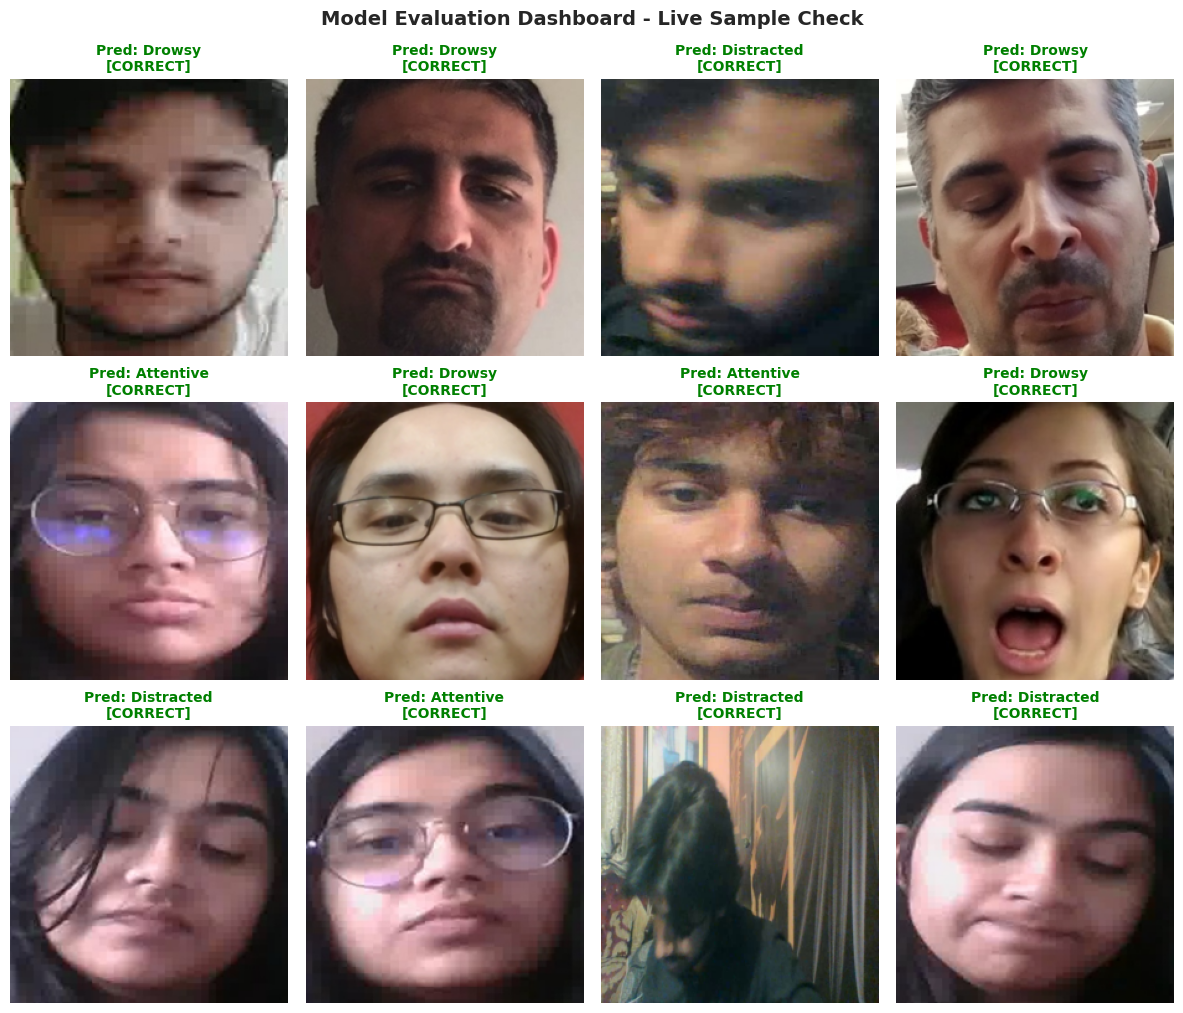

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import timm

# =====================================================================
# 1. Setup Configuration & Data Loader
# =====================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASET_DIR = '/kaggle/input/datasets/natalierobert/designproject-clean'
MODEL_WEIGHTS = '/kaggle/working/best_driver_state_model.pth'

# Simple evaluation transforms (no data augmentation like color jitters or flips)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Re-create the exact same validation split index mapping
full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=eval_transform)
class_names = full_dataset.classes  # ['Attentive', 'Distracted', 'Drowsy']

indices = np.arange(len(full_dataset))
targets = np.array(full_dataset.targets)
_, val_idx = train_test_split(indices, test_size=0.15, stratify=targets, random_state=42)

val_dataset = Subset(full_dataset, val_idx)
# Shuffle=True here lets us grab a completely random assortment of validation files every time you run it
viz_loader = DataLoader(val_dataset, batch_size=12, shuffle=True)

# =====================================================================
# 2. Reconstruct Model and Load Weights
# =====================================================================
print("Loading model for visual evaluation...")
model = timm.create_model('mobilenetv3_large_100', pretrained=False)
num_features = model.classifier.in_features
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(num_features, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 3)
)

if torch.os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()
    print("Weights loaded successfully!")
else:
    raise FileNotFoundError(f"Could not find model weights file at {MODEL_WEIGHTS}. Did you finish training?")

# =====================================================================
# 3. Pull Images, Predict, and Render Plot
# =====================================================================
# Grab a single batch of random samples
images, labels = next(iter(viz_loader))

# We need to normalize tensors specifically for evaluation matching
# but we display the un-normalized tensor images so the colors look normal on screen
norm_transforms = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
normalized_images = torch.stack([norm_transforms(img) for img in images]).to(DEVICE)

with torch.no_grad():
    outputs = model(normalized_images)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu().numpy()
labels = labels.numpy()

# Plot setup: 3 rows, 4 columns
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.ravel()

print("\nGenerating evaluation dashboard snapshot...")
for i in range(12):
    # Convert PyTorch tensor (C, H, W) back to NumPy standard image shape (H, W, C)
    np_img = images[i].permute(1, 2, 0).numpy()
    np_img = np.clip(np_img, 0, 1) # Force pixel clip limits to look crisp

    true_cls = class_names[labels[i]]
    pred_cls = class_names[preds[i]]

    axes[i].imshow(np_img)
    axes[i].axis('off') # Strip spatial axis borders for clean presentation

    # Check if prediction aligns with reality to dictate text coloring
    if pred_cls == true_cls:
        axes[i].set_title(f"Pred: {pred_cls}\n[CORRECT]", color='green', fontsize=10, fontweight='bold')
    else:
        axes[i].set_title(f"Pred: {pred_cls}\n(True: {true_cls})", color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle("Model Evaluation Dashboard - Live Sample Check", fontsize=14, fontweight='bold', y=1.02)
plt.show()